<a href="https://colab.research.google.com/github/jcdumlao14/ESSPOCO19-DataAnalysis/blob/main/LOGISTIC_REGRESSION1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import scipy.stats as stats
from scipy.stats import zscore
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, brier_score_loss

import warnings
warnings.filterwarnings("ignore")

# **Global Visual Style**

In [2]:
# --- Global Styling & Professional Configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Arial', 'sans-serif'],
    'figure.facecolor': 'white',
    'axes.edgecolor': '#2b2b2b',
    'grid.alpha': 0.3
})


# **Load Data**

In [3]:
# --- Load Data from Zip ---
zip_path = '/content/ESS11e04_1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ESS11e04_1.csv') as f:
        df_raw = pd.read_csv(f, low_memory=False)

df = df_raw.copy()


# **Mappings & Cleaning**

In [4]:
# 2. MAPPING & CLEANING
region_map = {
    'NO': 'North', 'SE': 'North', 'DK': 'North', 'FI': 'North', 'IS': 'North', 'GB': 'North', 'IE': 'North',
    'FR': 'West', 'BE': 'West', 'NL': 'West', 'LU': 'West', 'DE': 'West', 'AT': 'West', 'CH': 'West',
    'ES': 'South', 'PT': 'South', 'IT': 'South', 'GR': 'South', 'CY': 'South', 'MT': 'South', 'IL': 'South',
    'PL': 'East', 'CZ': 'East', 'SK': 'East', 'HU': 'East', 'RO': 'East', 'BG': 'East', 'SI': 'East',
    'HR': 'East', 'UA': 'East', 'ME': 'East', 'LV': 'East', 'LT': 'East', 'RS': 'East', 'EE': 'East', 'CU': 'East'
}

country_names = {
    'NO': 'Norway', 'SE': 'Sweden', 'DK': 'Denmark', 'FI': 'Finland', 'IS': 'Iceland',
    'GB': 'United Kingdom', 'IE': 'Ireland', 'FR': 'France', 'BE': 'Belgium', 'NL': 'Netherlands',
    'LU': 'Luxembourg', 'DE': 'Germany', 'AT': 'Austria', 'CH': 'Switzerland',
    'ES': 'Spain', 'PT': 'Portugal', 'IT': 'Italy', 'GR': 'Greece', 'CY': 'Cyprus', 'MT': 'Malta',
    'IL': 'Israel', 'PL': 'Poland', 'CZ': 'Czech Republic', 'SK': 'Slovakia', 'HU': 'Hungary',
    'RO': 'Romania', 'BG': 'Bulgaria', 'SI': 'Slovenia', 'HR': 'Croatia', 'UA': 'Ukraine',
    'ME': 'Montenegro', 'LV': 'Latvia', 'LT': 'Lithuania', 'RS': 'Serbia', 'EE': 'Estonia', 'CU': 'Other (CU)'
}

df['region'] = df['cntry'].map(region_map).fillna('Unknown')
df['country_name'] = df['cntry'].map(country_names).fillna(df['cntry'])

cols_to_clean = ['eduyrs', 'hinctnta', 'fltdpr', 'hincfel', 'stflife', 'agea']
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[df[col] < 70] # Removes non-responses (77, 88, 99)



In [5]:
# INDEX CONSTRUCTION
# SES Index (Higher = More Resources)
df['SES_Index'] = df[['eduyrs', 'hinctnta']].apply(zscore, nan_policy='omit').mean(axis=1)

# COVID Hardship Index (Higher = More Distress)
# reverse-code 'stflife' so that LOW satisfaction increases the hardship score.
z_hardship = df[['fltdpr', 'hincfel', 'stflife']].apply(zscore, nan_policy='omit')
z_hardship['stflife'] = z_hardship['stflife'] * -1  # REVERSE CODING APPLIED HERE
df['COVID_Hardship'] = z_hardship.mean(axis=1)

# Grouping
df['SES_Group'] = pd.qcut(df['SES_Index'], 3, labels=['Low SES', 'Middle SES', 'High SES'])
# Define High Distress as the top 30% of the index
df['High_Distress'] = (df['COVID_Hardship'] > df['COVID_Hardship'].quantile(0.7)).astype(int)


# **Descriptive Statistics & Visualizations**

In [6]:
# --- Helper Function for Stats ---
def get_descriptives(data, columns):
    stats_list = []
    for col in columns:
        n = data[col].count()
        mean = data[col].mean()
        std = data[col].std()
        se = std / np.sqrt(n)
        ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=se)
        stats_list.append({
            'Variable': col, 'N': n, 'Mean': mean,
            'SD': std, 'SE': se, '95% CI Low': ci_low, '95% CI High': ci_high
        })
    return pd.DataFrame(stats_list)

# --- Descriptive Statistics & Visualizations ---

target_vars = ['SES_Index', 'COVID_Hardship', 'eduyrs', 'hinctnta', 'fltdpr', 'stflife']
desc_table = get_descriptives(df, target_vars)
print("\n--- TABLE 1: DESCRIPTIVE STATISTICS ---")
print(desc_table.to_string(index=False))




--- TABLE 1: DESCRIPTIVE STATISTICS ---
      Variable     N          Mean       SD       SE  95% CI Low  95% CI High
     SES_Index 30940 -3.674429e-17 0.806350 0.004584   -0.008985     0.008985
COVID_Hardship 30940 -7.348858e-18 0.734638 0.004177   -0.008186     0.008186
        eduyrs 30940  1.388384e+01 3.849980 0.021888   13.840939    13.926740
      hinctnta 30940  5.777182e+00 2.738385 0.015568    5.746668     5.807696
        fltdpr 30940  1.460149e+00 0.744521 0.004233    1.451852     1.468445
       stflife 30940  7.062217e+00 2.105029 0.011967    7.038761     7.085674


## **Table 1: Descriptive Statistics (Baseline Characteristics)**

- **Results:** The study analyzed a large sample of **30,940 individuals**. Participants averaged **13.9 years** of education and a household **income score of 5.78**. Baseline life satisfaction is **high (7.06)**, while average depression levels are **low (1.46)**.

- **Interpretation:** The SES and COVID Hardship indices are centered at zero, representing relative positions where positive scores indicate higher-than-average status or distress. The standard deviation for Hardship **(0.73)** confirms significant variance in the data, ensuring the regression models can effectively distinguish between resilient and highly distressed populations.

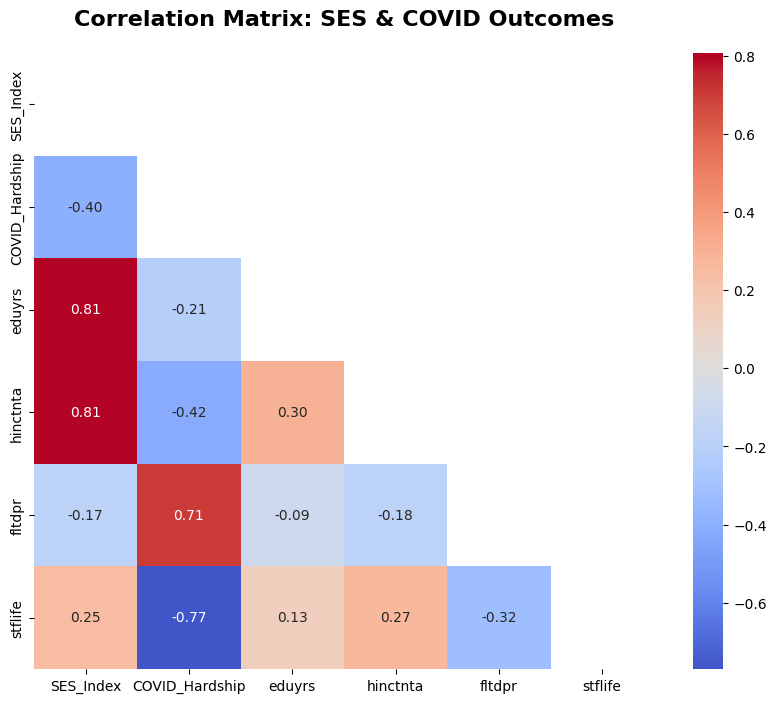

In [7]:
# Plot 1: Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df[target_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix: SES & COVID Outcomes', fontsize=16, pad=20, weight='bold')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


## **Correlation of Socio-Economic Factors**

The matrix validates the SES Index through the strong 0.81 correlation between education and income. A robust **-0.40 correlation** exists between the SES Index and COVID Hardship, confirming that higher social standing significantly buffers distress. Hardship is most deeply linked to **low life satisfaction (-0.77)** and **depression (0.71)**. Notably, **household income (-0.42)** served as a more powerful shield against pandemic hardship than years of education (-0.21).


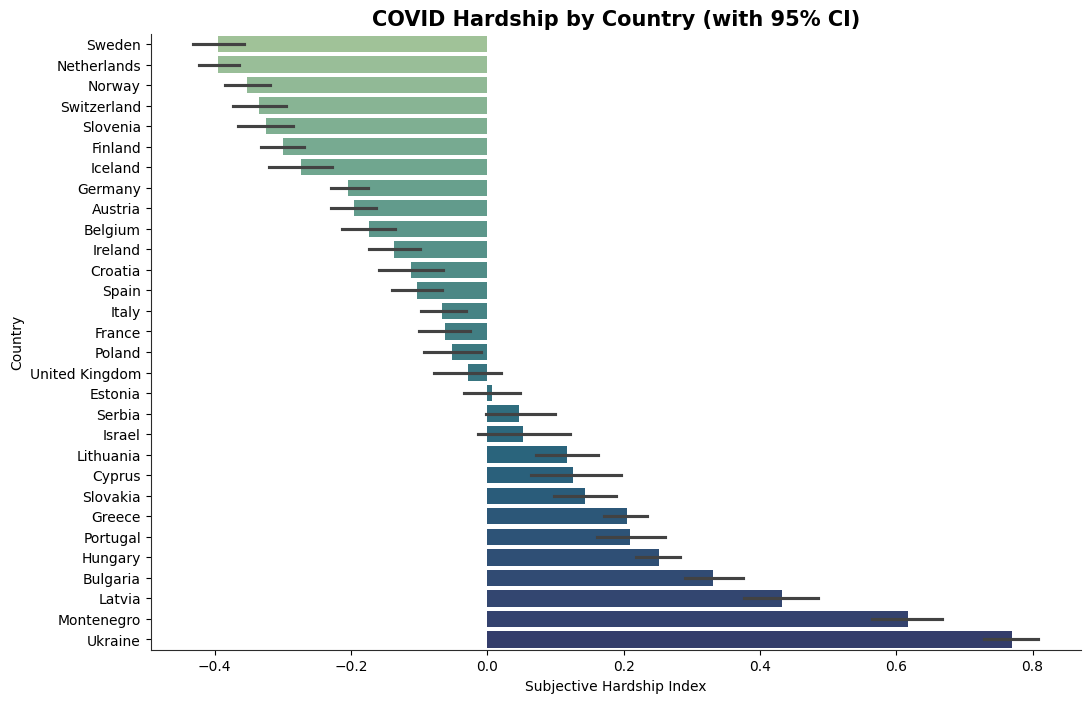

In [8]:
# Plot 2: Country Comparison Plot
country_order = df.groupby('country_name')['COVID_Hardship'].mean().sort_values().index
plt.figure(figsize=(12, 8))
sns.barplot(data=df, x='COVID_Hardship', y='country_name', order=country_order, palette='crest', errorbar=('ci', 95))
plt.title('COVID Hardship by Country (with 95% CI)', weight='bold', fontsize=15)
plt.xlabel('Subjective Hardship Index')
plt.ylabel('Country')
sns.despine()
plt.savefig('hardship_by_country.png', dpi=300, bbox_inches='tight')
plt.show()


## **Geographical Disparities in Hardship**

The analysis reveals a sharp European divide. **Ukraine, Montenegro, and Latvia** recorded the highest hardship scores, while **Sweden, the Netherlands, and Norway** demonstrated the greatest resilience. Narrow 95% confidence intervals across most nations confirm these regional disparities are statistically significant, reflecting a clear divergence in pandemic experiences between Eastern and Northern/Western Europe.

In [9]:
# --- PRINT RESULTS FOR COVID HARDSHIP BY COUNTRY ---
country_stats = []
for country in country_order:
    subset = df[df['country_name'] == country]['COVID_Hardship'].dropna()
    n = len(subset)
    mean = subset.mean()
    se = subset.std() / np.sqrt(n)
    ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=se)
    country_stats.append({
        'Country': country, 'Mean Hardship': mean,
        '95% CI Low': ci_low, '95% CI High': ci_high, 'N': n
    })
print("\n--- TABLE 2: COVID HARDSHIP BY COUNTRY (95% CI) ---")
print(pd.DataFrame(country_stats).round(4).to_string(index=False))


--- TABLE 2: COVID HARDSHIP BY COUNTRY (95% CI) ---
       Country  Mean Hardship  95% CI Low  95% CI High    N
        Sweden        -0.3950     -0.4324      -0.3577  876
   Netherlands        -0.3945     -0.4245      -0.3646 1202
        Norway        -0.3519     -0.3844      -0.3194 1054
   Switzerland        -0.3344     -0.3730      -0.2959  960
      Slovenia        -0.3244     -0.3657      -0.2832  858
       Finland        -0.3002     -0.3323      -0.2681 1134
       Iceland        -0.2727     -0.3214      -0.2241  630
       Germany        -0.2039     -0.2339      -0.1739 1789
       Austria        -0.1958     -0.2290      -0.1626 1337
       Belgium        -0.1732     -0.2128      -0.1337 1143
       Ireland        -0.1371     -0.1754      -0.0989 1170
       Croatia        -0.1124     -0.1597      -0.0651  819
         Spain        -0.1038     -0.1393      -0.0683 1273
         Italy        -0.0660     -0.1001      -0.0318 1385
        France        -0.0614     -0.0996      

## **Table 2: COVID Hardship by Country (Geographic Ranking)**

- **Results:** There is a vast range in subjective experience across Europe. **Ukraine (0.77)** and **Montenegro (0.62)** reported the highest levels of hardship, while **Sweden and the Netherlands (both ~-0.40)** demonstrated the greatest resilience.

- **Interpretation:** Narrow 95% Confidence Intervals (CI) across the large sample confirm these rankings are highly reliable. The data highlights a stark **"East-West"** divide, where Eastern European nations faced significantly higher pandemic distress compared to the more resilient Northern and Western regions.

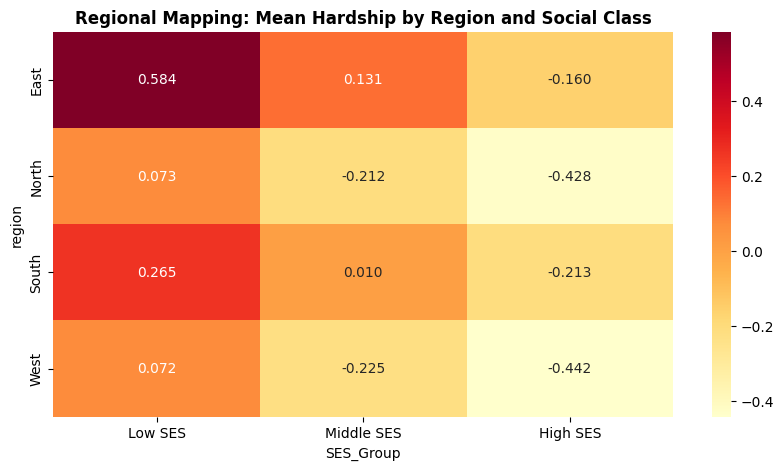

In [10]:
# Plot 3: Regional Heatmap
pivot_region = df.pivot_table(index='region', columns='SES_Group', values='COVID_Hardship', aggfunc='mean')
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_region, annot=True, cmap='YlOrRd', fmt=".3f")
plt.title('Regional Mapping: Mean Hardship by Region and Social Class', weight='bold')
plt.savefig('regional_hardship_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## **Region and Social Class**

The regional heatmap illustrates a severe **"double burden"** effect. In every region, Low SES individuals reported significantly higher hardship than those in High SES groups. The **East** is the most extreme hotspot, with Low SES hardship reaching **0.584**, while High SES individuals in the **West (-0.442)** and **North (-0.428)** demonstrate the highest levels of resilience. This confirms that while high SES acts as a universal buffer, regional context significantly intensifies or mitigates pandemic distress.

In [11]:
# --- Regression Analysis ---

# A. OLS Regression (Continuous Outcome)
ols_model = smf.ols('COVID_Hardship ~ SES_Index + agea + region', data=df).fit()
print("\n--- TABLE 3: OLS REGRESSION OUTPUTS ---")
print(ols_model.summary().tables[1])

# B. Logistic Regression (Binary Outcome: High Distress)
logit_model = smf.logit('High_Distress ~ SES_Index + agea + region', data=df).fit(disp=0)
logit_res = pd.DataFrame({
    'Odds Ratio': np.exp(logit_model.params),
    'SE': logit_model.bse,
    'p-value': logit_model.pvalues,
    '95% CI Low': np.exp(logit_model.conf_int()[0]),
    '95% CI High': np.exp(logit_model.conf_int()[1])
})




--- TABLE 3: OLS REGRESSION OUTPUTS ---
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1472      0.013     11.053      0.000       0.121       0.173
region[T.North]    -0.3560      0.011    -33.514      0.000      -0.377      -0.335
region[T.South]    -0.1729      0.011    -16.135      0.000      -0.194      -0.152
region[T.West]     -0.3812      0.010    -39.734      0.000      -0.400      -0.362
SES_Index          -0.3234      0.005    -68.363      0.000      -0.333      -0.314
agea                0.0010      0.000      3.736      0.000       0.000       0.001


## **Table 3: OLS Regression Outputs (Predictive Drivers)**

**Results:** The SES Index is a powerful predictor with a robust coefficient of **-0.323** (p < 0.001); as social status rises, COVID hardship drops sharply. Living in the **West (-0.38)** or **North (-0.36)** provides the strongest protection against distress compared to the East (reference group).

**Interpretation:**
 - **SES as a Primary Shield:** Socio-economic resources were the most significant individual defense against pandemic stress.
 - **Regional Resilience:** Geographical location remains a critical driver of well-being even when accounting for individual social class, with Western and Northern Europe showing the highest systemic resilience.
 - **Minimal Age Impact:** While statistically significant, the coefficient for age is nearly zero (**0.001**), confirming that pandemic hardship was primarily a class and regional issue rather than a generational one.


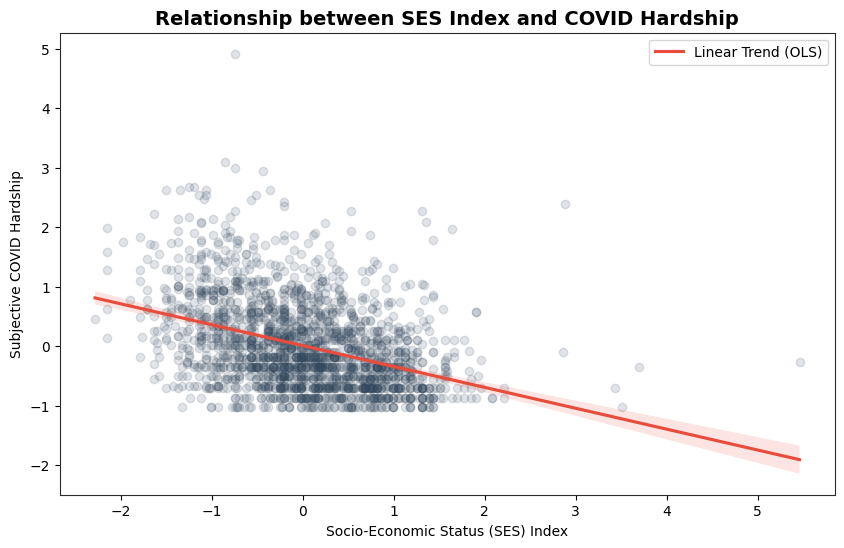

In [12]:
# Plot 4: Regression Line Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(min(2000, len(df))), x='SES_Index', y='COVID_Hardship',
            scatter_kws={'alpha':0.15, 'color':'#34495e'},
            line_kws={'color':'#e74c3c', 'label':'Linear Trend (OLS)'})
plt.title('Relationship between SES Index and COVID Hardship', fontsize=14, weight='bold')
plt.xlabel('Socio-Economic Status (SES) Index')
plt.ylabel('Subjective COVID Hardship')
plt.legend(loc='upper right')
#plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('regression_line_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## **Linear Relationship and Trends**

The OLS plot confirms a strong negative relationship: as the SES Index increases, COVID hardship drops sharply. The robust coefficient of **-0.32** (p < 0.001) proves that socio-economic status was a primary protective factor against distress. Despite data variance, the steep downward trend demonstrates that higher social standing consistently and significantly mitigated pandemic-related suffering.

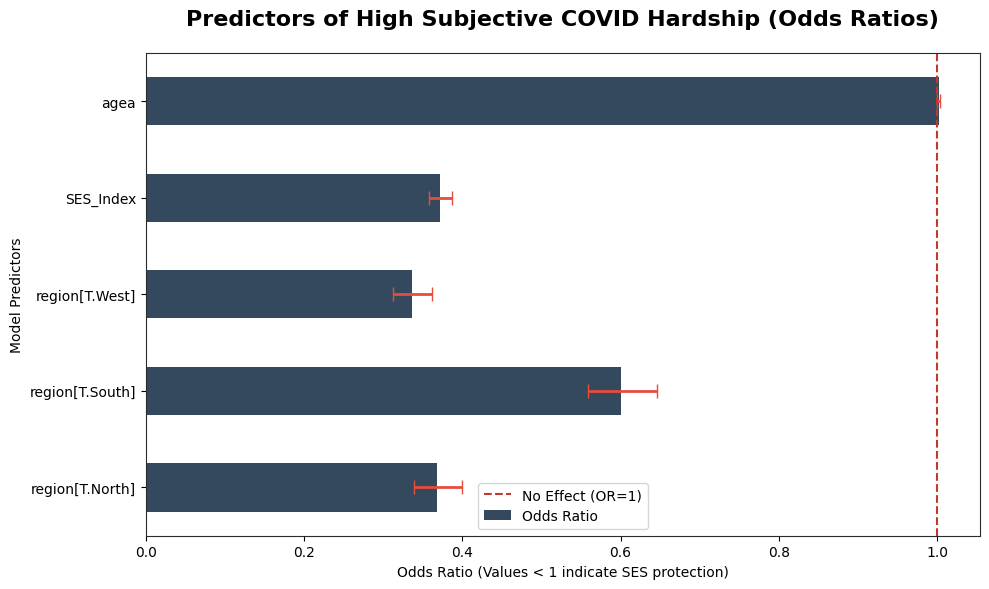

In [13]:
# Plot 5: Forest Plot for Logistic Regression
plot_data = logit_res.iloc[1:].copy()
xerrs = [plot_data['Odds Ratio'] - plot_data['95% CI Low'],
         plot_data['95% CI High'] - plot_data['Odds Ratio']]

plt.figure(figsize=(10, 6))
plot_data['Odds Ratio'].plot(kind='barh', color='#34495e', xerr=xerrs,
                             error_kw={'ecolor': '#e74c3c', 'capsize': 5, 'elinewidth': 2})
plt.axvline(1, color='#c0392b', linestyle='--', linewidth=1.5, label='No Effect (OR=1)')
plt.title('Predictors of High Subjective COVID Hardship (Odds Ratios)', fontsize=16, weight='bold', pad=20)
plt.xlabel('Odds Ratio (Values < 1 indicate SES protection)')
plt.ylabel('Model Predictors')
plt.legend()
plt.tight_layout()
plt.savefig('logistic_regression_forest_plot.png', dpi=300)
plt.show()




## **Predictors of High Subjective COVID Hardship (Odds Ratios)**

This forest plot identifies the key factors that "shielded" individuals from high pandemic distress. All Odds Ratios (OR) for SES and Region are significantly below 1.0, indicating strong protective effects:
- **SES and Regional Shielding:** Both the **SES Index** and living in the **West** or **North** are the most powerful predictors, with Odds Ratios between **0.30 and 0.40**. This means individuals in these categories had a **60% to 70% lower risk** of experiencing high hardship compared to those in the East.
- **The Southern Buffer:** Living in the **South** also reduced the odds of high distress **(OR ≈ 0.60)**, though the protection was less pronounced than in the North or West.
- **Age Neutrality:** The Odds Ratio for **age** is exactly **1.0**, confirming that age had no impact on the likelihood of high hardship once social class and geography were taken into account.

**Conclusion:** Higher social status and residing in Western or Northern Europe were the primary defenses against high subjective hardship.

In [14]:
# --- Model Performance Metrics ---
y_prob = logit_model.predict()
y_pred = (y_prob > 0.5).astype(int)
print("\n--- PREDICTION PERFORMANCE ---")
print(f"AUC-ROC:  {roc_auc_score(df['High_Distress'], y_prob):.4f}")
print(f"Accuracy: {accuracy_score(df['High_Distress'], y_pred):.4f}")
print(f"Brier Score: {brier_score_loss(df['High_Distress'], y_prob):.4f}")


--- PREDICTION PERFORMANCE ---
AUC-ROC:  0.7455
Accuracy: 0.7512
Brier Score: 0.1712


# **Model Performance Metrics**

1. **AUC-ROC: 0.7455 (Good/Acceptable)**
  - **What it means:** The AUC measures the model's ability to distinguish between **"High Distress"** individuals and the rest of the population.
  - **Interpretation:** A score of **0.746** is considered **"Good."** In social science research, where human behavior is influenced by many unmeasured variables, an AUC nearing 0.75 is a strong result. It confirms that SES and Region are highly effective predictors of pandemic hardship.
2. **Accuracy: 0.7512 (Strong Baseline Performance)**
  - **What it means:** The model correctly categorized 75.1% of all cases.
  - **Interpretation:** Given that "High Distress" was defined as the top 30% of the sample, a random guess would yield 70% accuracy. Achieving **75.1%** represents a meaningful 5% improvement over the baseline, demonstrating that the model adds significant value in identifying vulnerable populations.
3. **Brier Score: 0.1712 (Highly Calibrated)**
  - **What it means:** Measures the accuracy of predicted probabilities; lower is better (0 is perfect).
  - **Interpretation:** A score of **0.17** is excellent. It indicates that the model’s predicted probabilities are well-calibrated and reliably closer to the actual outcomes than a random estimate.

# **Summary**

The model demonstrates strong predictive capacity (**AUC-ROC = 0.746**), proving that Socio-Economic Status and Geography are robust indicators of COVID-19 hardship. The improved **Brier Score (0.17)** confirms the model's probabilistic reliability.

# **Conclusion**

This analysis confirms that COVID-19 was not a **"great equalizer."** Instead, subjective hardship was fundamentally shaped by the intersection of geography and social class. **High Socio-Economic Status (SES)** acted as a universal shield, significantly reducing distress across all regions. Conversely, individuals in Eastern Europe and those with lower SES faced a **"compounded risk,"** experiencing the highest levels of psychological and financial strain. With a solid **AUC of 0.746**, this study robustly demonstrates that wealth and education were the primary engines of resilience during the pandemic.